[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mahdiabolghasemi/Introduction-To-Machine-Learning/blob/DSB102-S2-2026/Workshops/Week4-lab-Soln.ipynb)


# Week 4 — Classification

**Topics:** Logistic regression, Naive Bayes, KNN, confusion matrix, ROC

---
### Setup — run this cell first

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              roc_curve, ConfusionMatrixDisplay, accuracy_score)
import warnings; warnings.filterwarnings('ignore')

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)

# sklearn's target has 0=malignant, 1=benign. We flip this so Malignant=1 is
# the positive class (the condition being tested for) and Benign=0 is
# negative -- the way you'd describe a medical test (positive test = disease
# present). This also makes confusion-matrix language line up: "malignant
# diagnosed as benign" is then genuinely a false NEGATIVE, matching how the
# exercises below describe it.
y = pd.Series(1 - data.target, name='Malignant')

print(f"Samples: {len(y)}   Features: {X.shape[1]}")
print(f"Benign (0): {(y==0).sum()}   Malignant (1): {(y==1).sum()}")

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=17, stratify=y)
sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr);  X_te_sc = sc.transform(X_te)

Samples: 569   Features: 30
Benign (0): 357   Malignant (1): 212


---
## Part 1 — Logistic Regression

### 1.1 Tutorial: fit, predict, confusion matrix

Accuracy: 0.965
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



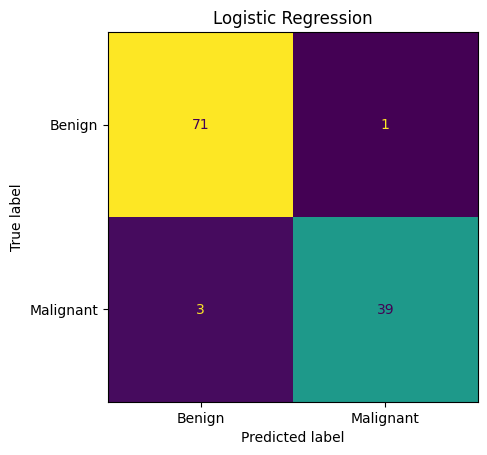

In [2]:
# Tutorial: logistic regression
# sklearn's LogisticRegression applies L2 regularisation by default -- this
# keeps coefficients from blowing up on features that separate the classes
# almost perfectly (several of these 30 features do). Because the penalty
# is applied equally to every coefficient, features need to be on the same
# scale first, so we fit on the *scaled* training data -- same rule as
# ridge/lasso in Week 3.
lr = LogisticRegression(max_iter=1000).fit(X_tr_sc, y_tr)
y_pred_lr = lr.predict(X_te_sc)

# predict_proba() returns, for every test row, two probabilities: P(Benign)
# and P(Malignant), which sum to 1. Column 1 is P(Malignant | x) since
# Malignant is our positive class -- we'll use this for the threshold
# exercise below and for the ROC curve in Part 4.
y_prob_lr = lr.predict_proba(X_te_sc)[:, 1]

print(f"Accuracy: {accuracy_score(y_te, y_pred_lr):.3f}")
print(classification_report(y_te, y_pred_lr, target_names=['Benign','Malignant']))

ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred_lr, display_labels=['Benign','Malignant'], colorbar=False)
plt.title('Logistic Regression'); plt.show()

### 🔧 Exercise 1 — Adjust the decision threshold

In cancer screening, a **false negative** (a malignant sample predicted as benign) is far more harmful than a false positive (a benign sample predicted as malignant) — missing a cancer is worse than an unnecessary follow-up test.

**Tasks:**
1. Lower the classification threshold: predict `Malignant` when `P(Malignant|x) >= 0.3` (instead of the default 0.5).
2. Print the new confusion matrix and classification report.
3. How many more malignant cases are now caught? What is the trade-off?
4. Using `precision_score` and `recall_score` (from `sklearn.metrics`), compute precision and recall for the **Malignant** class at both thresholds (0.5 and 0.3). Which threshold gives better recall? What is the cost?

Accuracy at threshold=0.3: 0.974
              precision    recall  f1-score   support

      Benign       0.99      0.97      0.98        72
   Malignant       0.95      0.98      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



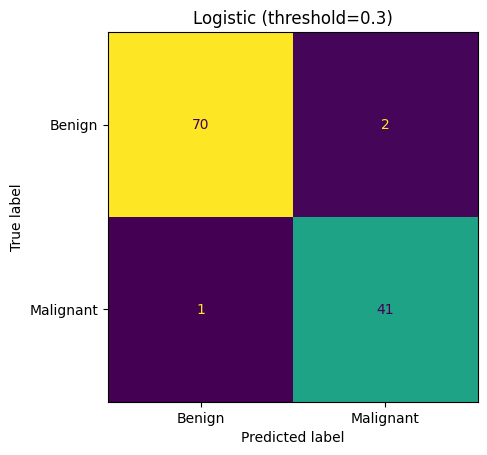

Threshold=0.5  Precision(Malignant)=0.975  Recall(Malignant)=0.929
Threshold=0.3  Precision(Malignant)=0.953  Recall(Malignant)=0.976


In [3]:
# ── SOLUTION Exercise 1 ──────────────────────────────────────────────────────
# Lowering the threshold means less evidence is needed before predicting
# Malignant, so recall for Malignant should go up (fewer misses) at some
# cost to precision (more false alarms).
y_pred_thresh = (y_prob_lr >= 0.3).astype(int)   # predict Malignant if P(Malignant) >= 0.3

print(f"Accuracy at threshold=0.3: {accuracy_score(y_te, y_pred_thresh):.3f}")
print(classification_report(y_te, y_pred_thresh, target_names=['Benign','Malignant']))
ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred_thresh, display_labels=['Benign','Malignant'], colorbar=False)
plt.title('Logistic (threshold=0.3)'); plt.show()

# ── Precision / Recall at both thresholds ─────────────────────────────────────
from sklearn.metrics import precision_score, recall_score
# Malignant is now label 1 (the positive class), so precision_score and
# recall_score already default to it -- no need for pos_label=0 anymore.
for thresh, preds in [(0.5, y_pred_lr), (0.3, y_pred_thresh)]:
    p = precision_score(y_te, preds)
    r = recall_score(y_te, preds)
    print(f"Threshold={thresh}  Precision(Malignant)={p:.3f}  Recall(Malignant)={r:.3f}")
# Lower threshold -> higher recall (catches more true malignant cases) at
# the cost of lower precision (a few more false alarms).

---
## Part 2 — Naive Bayes

### 2.1 Tutorial: Gaussian Naive Bayes

In [4]:
# Tutorial: Naive Bayes
# Unlike logistic regression, Gaussian Naive Bayes fits a separate mean and
# variance per feature per class, so each feature is already handled on its
# own scale -- it doesn't need standardised features. Scaling can even
# slightly hurt accuracy here, so we fit on the raw (unscaled) data.
nb = GaussianNB().fit(X_tr, y_tr)
y_pred_nb = nb.predict(X_te)
y_prob_nb = nb.predict_proba(X_te)[:, 1]   # P(Malignant | x)
print(f"Naive Bayes accuracy: {accuracy_score(y_te, y_pred_nb):.3f}")

Naive Bayes accuracy: 0.939


### 🔧 Exercise 2 — Naive Bayes and feature correlation

**Tasks:**
1. Compute the pairwise correlation of the first 6 features: `X_tr.iloc[:,:6].corr()`.
2. Do the features satisfy the Naive Bayes independence assumption?
3. Naive Bayes still works reasonably here — why?

In [5]:
# ── SOLUTION Exercise 2 ──────────────────────────────────────────────────────
print("Correlation matrix (first 6 features):")
print(X_tr.iloc[:, :6].corr().round(2))
print(f"\nNaive Bayes accuracy: {accuracy_score(y_te, y_pred_nb):.3f}")
print("Features ARE correlated -- the NB independence assumption is violated.")
print("Despite this, NB still gives reasonable accuracy because the")
print("class-conditional means differ enough to separate the classes.")

Correlation matrix (first 6 features):
                  mean radius  mean texture  mean perimeter  mean area  \
mean radius              1.00          0.31            1.00       0.99   
mean texture             0.31          1.00            0.32       0.31   
mean perimeter           1.00          0.32            1.00       0.99   
mean area                0.99          0.31            0.99       1.00   
mean smoothness          0.17         -0.03            0.21       0.18   
mean compactness         0.49          0.22            0.54       0.49   

                  mean smoothness  mean compactness  
mean radius                  0.17              0.49  
mean texture                -0.03              0.22  
mean perimeter               0.21              0.54  
mean area                    0.18              0.49  
mean smoothness              1.00              0.67  
mean compactness             0.67              1.00  

Naive Bayes accuracy: 0.939
Features ARE correlated -- the NB i

---
## Part 3 — K-Nearest Neighbours

### 3.1 Tutorial: KNN with K=5

In [6]:
# Tutorial: KNN
# KNN classifies a point by the majority class among its K nearest
# neighbours in feature space, measured by Euclidean distance. Distance-
# based methods DO need scaled features: without scaling, a feature
# measured in the hundreds (e.g. mean area) would dominate the distance
# calculation over one measured in fractions (e.g. mean smoothness).
knn5 = KNeighborsClassifier(n_neighbors=5).fit(X_tr_sc, y_tr)
print(f"KNN(K=5) test accuracy: {accuracy_score(y_te, knn5.predict(X_te_sc)):.3f}")

KNN(K=5) test accuracy: 0.974


### 🔧 Exercise 3 — Tune K and compare classifiers

**Tasks:**
1. Test K = 1, 3, 5, 10, 20, 50. Plot test accuracy vs K.
2. Which K gives the best accuracy?
3. Complete this comparison table (fill in test accuracies):

| Model | Accuracy |
|---|---|
| Logistic Regression | |
| Naive Bayes | |
| KNN (best K) | |

4. Which model would you recommend? Consider both accuracy and interpretability.

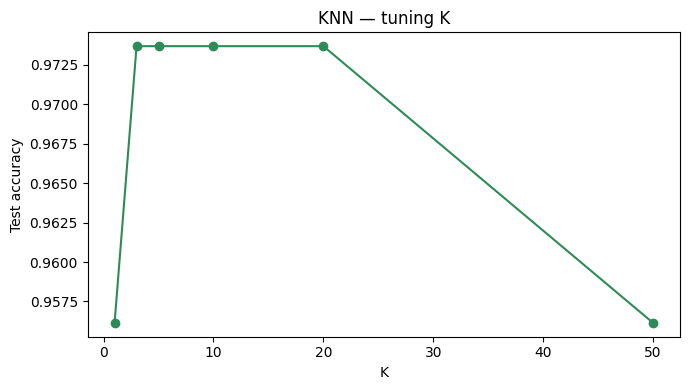

Best K: 3  accuracy: 0.974

Model comparison:
  Logistic       : 0.965
  NaiveBayes     : 0.939
  KNN(K=3)       : 0.974


In [7]:
# ── SOLUTION Exercise 3 ──────────────────────────────────────────────────────
ks = [1, 3, 5, 10, 20, 50]
accs = [accuracy_score(y_te, KNeighborsClassifier(k).fit(X_tr_sc,y_tr).predict(X_te_sc))
        for k in ks]

plt.figure(figsize=(7, 4))
plt.plot(ks, accs, 'o-', color='seagreen')
plt.xlabel('K'); plt.ylabel('Test accuracy'); plt.title('KNN — tuning K')
plt.tight_layout(); plt.show()

k_best = ks[np.argmax(accs)]
print(f"Best K: {k_best}  accuracy: {max(accs):.3f}")
print("\nModel comparison:")
for name, acc in [('Logistic', accuracy_score(y_te,y_pred_lr)),
                   ('NaiveBayes',accuracy_score(y_te,y_pred_nb)),
                   (f'KNN(K={k_best})', max(accs))]:
    print(f"  {name:15s}: {acc:.3f}")

---
## Part 4 — ROC Curves

### 4.1 Tutorial: compare classifiers visually

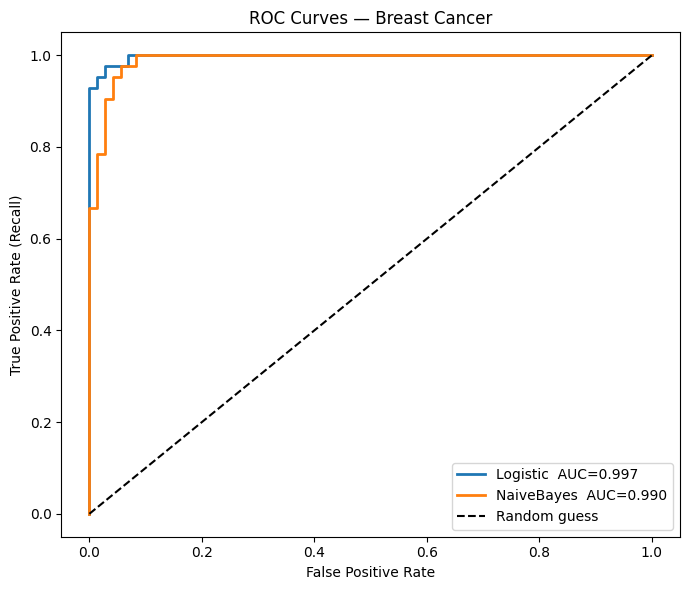

In [8]:
# Tutorial: ROC curves
# roc_curve sweeps the classification threshold from 0 to 1 and, at each
# value, records the false positive rate (FPR) and true positive rate
# (TPR, i.e. recall). Plotting TPR against FPR traces the ROC curve; the
# area under it (AUC) summarises performance across every possible
# threshold at once, not just the default 0.5.
fig, ax = plt.subplots(figsize=(7, 6))
for name, probs in [
    ('Logistic',  y_prob_lr),
    ('NaiveBayes',y_prob_nb),
]:
    fpr, tpr, _ = roc_curve(y_te, probs)
    ax.plot(fpr, tpr, lw=2, label=f'{name}  AUC={roc_auc_score(y_te,probs):.3f}')

ax.plot([0,1],[0,1],'k--', label='Random guess')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate (Recall)',
       title='ROC Curves — Breast Cancer')
ax.legend(); plt.tight_layout(); plt.show()

### 🔧 Exercise 4 — Add KNN to the ROC comparison

**Tasks:**
1. Add KNN (best K) to the ROC plot. Use `predict_proba`.
2. Which classifier has the highest AUC?
3. For cancer screening, would you choose a model based on AUC alone? What else matters?

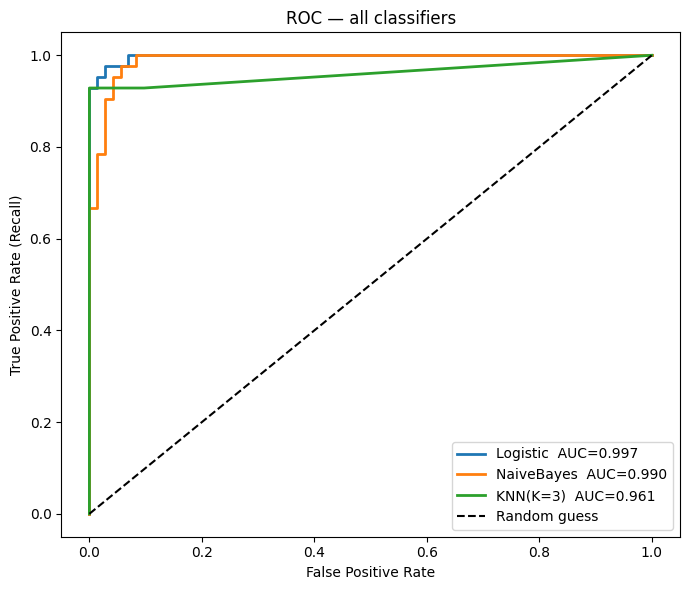

In [9]:
# ── SOLUTION Exercise 4 ──────────────────────────────────────────────────────
knn_best = KNeighborsClassifier(k_best).fit(X_tr_sc, y_tr)
y_prob_knn = knn_best.predict_proba(X_te_sc)[:, 1]

fig, ax = plt.subplots(figsize=(7, 6))
for name, probs in [
    ('Logistic',   y_prob_lr),
    ('NaiveBayes', y_prob_nb),
    (f'KNN(K={k_best})', y_prob_knn),
]:
    fpr, tpr, _ = roc_curve(y_te, probs)
    ax.plot(fpr, tpr, lw=2, label=f'{name}  AUC={roc_auc_score(y_te,probs):.3f}')
ax.plot([0,1],[0,1],'k--', label='Random guess')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate (Recall)',
       title='ROC — all classifiers')
ax.legend(); plt.tight_layout(); plt.show()
# For cancer screening we care most about recall (catching malignant cases)
# at a threshold we choose deliberately -- AUC alone doesn't tell us that.

---
## Summary

| Classifier | Key assumption | Needs scaled features? | Strength |
|---|---|---|---|
| **Logistic Regression** | Linear log-odds | Yes (regularised by default) | Interpretable, probabilities |
| **Naive Bayes** | Conditional feature independence | No | Fast; works with many features |
| **KNN** | None | Yes (distance-based) | Flexible; no parametric form |

Malignant is coded as the positive class (1) throughout, so "false negative" always means a missed cancer and "false positive" always means an unnecessary follow-up test.